In [1]:
import sys

sys.path.append("../..")
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
from layers.hyperset import HyperSETLayer

hyperset_layer = HyperSETLayer(feats=3, mlp_hidden=3, head=1)

In [3]:
torch.nn.init.orthogonal_(hyperset_layer.mlp.weight)
x = torch.randn(100, 196, 3)
alpha = 1.0  # 1.0
beta = 0.4  # 25.0
x_list = []
E_list = []
E_attn_list = []
E_ff_list = []
for recur in range(12):
    attn = hyperset_layer.attn(x)
    x = x - alpha * attn
    x = x + beta * F.linear(F.relu(hyperset_layer.ln2(hyperset_layer.mlp(x))), hyperset_layer.mlp.weight.t())

    x_proj = F.linear(x, hyperset_layer.mlp.weight)
    x_proj_rms = F.rms_norm(x_proj, (x_proj.shape[-1],))

    x_list.append(x_proj_rms.cpu().detach().numpy())

3


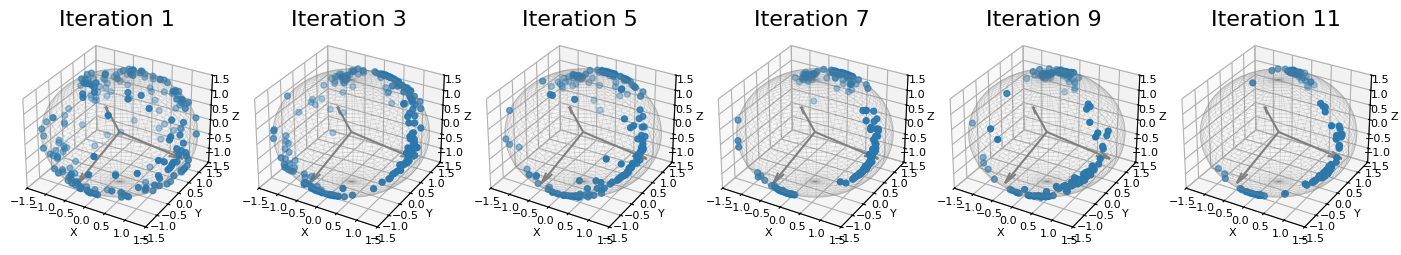

In [4]:
fig, ax = plt.subplots(
    1,
    6,
    figsize=(14, 10),
    subplot_kw={"projection": "3d"},  # (7.0, 5.0)
)  # neurips
ax = ax.flatten()
plt.rc("text", usetex=True)
plt.rc("font", family="times")
plt.rc("text.latex", preamble=r"\usepackage{mathptmx}")  # Use Times font in LaTeX

# Generating data for a spherical surface
theta = np.linspace(0, 2 * np.pi, 50)
phi = np.linspace(0, np.pi, 50)
theta, phi = np.meshgrid(theta, phi)
print(x_proj_rms.shape[-1])
r = math.sqrt(x_proj_rms.shape[-1])
x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)

basis_vectors = hyperset_layer.mlp.weight  # (out, in)
basis_vectors = basis_vectors / basis_vectors.norm(dim=1, keepdim=True)  # Normalize the basis vectors
basis_vectors = basis_vectors.cpu().detach().numpy()

for it, iteration in enumerate(range(0, 12, 2)):
    scatter_data = x_list[iteration][2]
    # Plot wireframe with custom color and line style
    ax[it].plot_wireframe(x, y, z, linewidth=0.5, alpha=0.2, color="gray")
    # Scatter plot with custom color, size, and transparency
    ax[it].scatter(
        scatter_data[:, 0],
        scatter_data[:, 1],
        scatter_data[:, 2],
        s=18,  # c="#009dd6"
    )

    origin = np.zeros(3)
    for basis_idx, basis in enumerate(basis_vectors):
        # Scale the basis vectors for better visualization
        arrow = basis * r  # Scale by sphere radius
        # Plot arrow
        ax[it].quiver(
            origin[0],
            origin[1],
            origin[2],
            arrow[0],
            arrow[1],
            arrow[2],
            color="grey",
            #  alpha=0.6,
            arrow_length_ratio=0.2,
        )

    # Set axis limits for better visualization
    ax[it].set_xlim([-1.5, 1.5])
    ax[it].set_ylim([-1.5, 1.5])
    ax[it].set_zlim([-1.5, 1.5])

    # Add grid and labels
    ax[it].grid(True, linestyle="--", alpha=0.5)
    ax[it].set_xlabel("X", fontsize=8, labelpad=-8)
    ax[it].set_ylabel("Y", fontsize=8, labelpad=-8)
    ax[it].set_zlabel("Z", fontsize=8, labelpad=-10)
    ax[it].tick_params(axis="both", which="major", labelsize=8, pad=-4)  # Reduce tick label size and padding
    ax[it].tick_params(axis="both", which="minor", labelsize=8, pad=-4)  # Adjust minor ticks if needed
    # Set title for each subplot
    ax[it].set_title(f"Iteration {iteration + 1}", fontsize=16, pad=-9)

fig.patch.set_facecolor("white")
plt.tight_layout(w_pad=1.5)
# plt.savefig(
#     "dynamics_on_hypersphere_high_dim_flatten.pdf", bbox_inches="tight", dpi=300
# )
plt.show()